# Initial Results and Code
## Labour Market Integration of Immigrants in Canada
### Milestone 3 - Proof of Concept

Preparation

In [7]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


Data Loading

In [8]:
# 2. Load dataset
df = pd.read_csv("../data/raw/LFS_98100442.csv")

# Preview the dataset
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (25401600, 32)


,REF_DATE,GEO,DGUID,Gender (3),Age (15A),Labour force status (8),Major field of study - Classification of Instructional Programs (CIP) 2021 (63),Location of study (5),"Highest certificate, diploma or degree (16)",Coordinate,...,Immigrant status and period of immigration (11):2001 to 2010[7],Symbol.6,Immigrant status and period of immigration (11):2011 to 2021[8],Symbol.7,Immigrant status and period of immigration (11):2011 to 2015[9],Symbol.8,Immigrant status and period of immigration (11):2016 to 2021[10],Symbol.9,Immigrant status and period of immigration (11):Non-permanent residents[11],Symbol.10
0,2021,Canada,2021A000011124,Total - Gender,Total - Age,Total - Labour force status,Total - Major field of study - Classification ...,Total - Location of study,"Total - Highest certificate, diploma or degree",1.1.1.1.1.1.1,...,1898570.0,NaN,2105120.0,NaN,1003595.0,NaN,1101525.0,NaN,837125.0,NaN
1,2021,Canada,2021A000011124,Total - Gender,Total - Age,Total - Labour force status,Total - Major field of study - Classification ...,Total - Location of study,"No certificate, diploma or degree",1.1.1.1.1.1.2,...,229775.0,NaN,281260.0,NaN,138285.0,NaN,142980.0,NaN,63670.0,NaN
2,2021,Canada,2021A000011124,Total - Gender,Total - Age,Total - Labour force status,Total - Major field of study - Classification ...,Total - Location of study,High (secondary) school diploma or equivalency...,1.1.1.1.1.1.3,...,411965.0,NaN,403955.0,NaN,210165.0,NaN,193790.0,NaN,183755.0,NaN
3,2021,Canada,2021A000011124,Total - Gender,Total - Age,Total - Labour force status,Total - Major field of study - Classification ...,Total - Location of study,"Postsecondary certificate, diploma or degree",1.1.1.1.1.1.4,...,1256825.0,NaN,1419900.0,NaN,655150.0,NaN,764750.0,NaN,589710.0,NaN
4,2021,Canada,2021A000011124,Total - Gender,Total - Age,Total - Labour force status,Total - Major field of study - Classification ...,Total - Location of study,Postsecondary certificate or diploma below bac...,1.1.1.1.1.1.5,...,429915.0,NaN,419120.0,NaN,217510.0,NaN,201615.0,NaN,189765.0,NaN


In [9]:
# 3. Inspect columns
print("Columns:")
display(df.columns.tolist())

Columns:


['REF_DATE',
 'GEO',
 'DGUID',
 'Gender (3)',
 'Age (15A)',
 'Labour force status (8)',
 'Major field of study - Classification of Instructional Programs (CIP) 2021 (63)',
 'Location of study (5)',
 'Highest certificate, diploma or degree (16)',
 'Coordinate',
 'Immigrant status and period of immigration (11):Total - Immigrant status and period of immigration[1]',
 'Symbol',
 'Immigrant status and period of immigration (11):Non-immigrants[2]',
 'Symbol.1',
 'Immigrant status and period of immigration (11):Immigrants[3]',
 'Symbol.2',
 'Immigrant status and period of immigration (11):Before 1980[4]',
 'Symbol.3',
 'Immigrant status and period of immigration (11):1980 to 1990[5]',
 'Symbol.4',
 'Immigrant status and period of immigration (11):1991 to 2000[6]',
 'Symbol.5',
 'Immigrant status and period of immigration (11):2001 to 2010[7]',
 'Symbol.6',
 'Immigrant status and period of immigration (11):2011 to 2021[8]',
 'Symbol.7',
 'Immigrant status and period of immigration (11):2011 t

Data Cleaning

In [10]:
# 4. Data cleaning
# Create a working copy of the dataset
df_clean = df.copy()

# Keep only meaningful labour force categories
df_clean = df_clean[
    df_clean["Labour force status (8)"] != "Total - Labour force status"
].copy()

# Keep only specific education categories
df_clean = df_clean[
    df_clean["Highest certificate, diploma or degree (16)"]
    != "Total - Highest certificate, diploma or degree"
].copy()

print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())

Cleaned dataset shape: (20837250, 32)


,REF_DATE,GEO,DGUID,Gender (3),Age (15A),Labour force status (8),Major field of study - Classification of Instructional Programs (CIP) 2021 (63),Location of study (5),"Highest certificate, diploma or degree (16)",Coordinate,...,Immigrant status and period of immigration (11):2001 to 2010[7],Symbol.6,Immigrant status and period of immigration (11):2011 to 2021[8],Symbol.7,Immigrant status and period of immigration (11):2011 to 2015[9],Symbol.8,Immigrant status and period of immigration (11):2016 to 2021[10],Symbol.9,Immigrant status and period of immigration (11):Non-permanent residents[11],Symbol.10
5041,2021,Canada,2021A000011124,Total - Gender,Total - Age,In the labour force,Total - Major field of study - Classification ...,Total - Location of study,"No certificate, diploma or degree",1.1.1.2.1.1.2,...,92635.0,NaN,107340.0,NaN,54325.0,NaN,53020.0,NaN,25410.0,NaN
5042,2021,Canada,2021A000011124,Total - Gender,Total - Age,In the labour force,Total - Major field of study - Classification ...,Total - Location of study,High (secondary) school diploma or equivalency...,1.1.1.2.1.1.3,...,263410.0,NaN,261635.0,NaN,137365.0,NaN,124275.0,NaN,111780.0,NaN
5043,2021,Canada,2021A000011124,Total - Gender,Total - Age,In the labour force,Total - Major field of study - Classification ...,Total - Location of study,"Postsecondary certificate, diploma or degree",1.1.1.2.1.1.4,...,1034655.0,NaN,1169875.0,NaN,543055.0,NaN,626820.0,NaN,483585.0,NaN
5044,2021,Canada,2021A000011124,Total - Gender,Total - Age,In the labour force,Total - Major field of study - Classification ...,Total - Location of study,Postsecondary certificate or diploma below bac...,1.1.1.2.1.1.5,...,341765.0,NaN,330830.0,NaN,174765.0,NaN,156070.0,NaN,155735.0,NaN
5045,2021,Canada,2021A000011124,Total - Gender,Total - Age,In the labour force,Total - Major field of study - Classification ...,Total - Location of study,Apprenticeship or trades certificate or diploma,1.1.1.2.1.1.6,...,66135.0,NaN,68260.0,NaN,37475.0,NaN,30780.0,NaN,22365.0,NaN


Exploratory Analysis

In [11]:
# 5. Identify immigrant-related columns
immigrant_cols = [col for col in df_clean.columns if "Immigrant status" in col]

print("Immigrant-related columns:")
display(immigrant_cols)

Immigrant-related columns:


['Immigrant status and period of immigration (11):Total - Immigrant status and period of immigration[1]',
 'Immigrant status and period of immigration (11):Non-immigrants[2]',
 'Immigrant status and period of immigration (11):Immigrants[3]',
 'Immigrant status and period of immigration (11):Before 1980[4]',
 'Immigrant status and period of immigration (11):1980 to 1990[5]',
 'Immigrant status and period of immigration (11):1991 to 2000[6]',
 'Immigrant status and period of immigration (11):2001 to 2010[7]',
 'Immigrant status and period of immigration (11):2011 to 2021[8]',
 'Immigrant status and period of immigration (11):2011 to 2015[9]',
 'Immigrant status and period of immigration (11):2016 to 2021[10]',
 'Immigrant status and period of immigration (11):Non-permanent residents[11]']

In [12]:
# 6. Explore labour force categories
print("Unique labour force categories:")
display(df_clean["Labour force status (8)"].unique())

Unique labour force categories:


<StringArray>
[    'In the labour force',                'Employed',
              'Unemployed', 'Not in the labour force',
      'Participation rate',         'Employment rate',
       'Unemployment rate']
Length: 7, dtype: str

In [13]:
# 7. Restrict data to employed vs unemployed for modeling
df_model = df_clean[
    df_clean["Labour force status (8)"].isin(["Employed", "Unemployed"])
].copy()

print("Model dataset shape:", df_model.shape)
display(df_model.head())

Model dataset shape: (5953500, 32)


,REF_DATE,GEO,DGUID,Gender (3),Age (15A),Labour force status (8),Major field of study - Classification of Instructional Programs (CIP) 2021 (63),Location of study (5),"Highest certificate, diploma or degree (16)",Coordinate,...,Immigrant status and period of immigration (11):2001 to 2010[7],Symbol.6,Immigrant status and period of immigration (11):2011 to 2021[8],Symbol.7,Immigrant status and period of immigration (11):2011 to 2015[9],Symbol.8,Immigrant status and period of immigration (11):2016 to 2021[10],Symbol.9,Immigrant status and period of immigration (11):Non-permanent residents[11],Symbol.10
10081,2021,Canada,2021A000011124,Total - Gender,Total - Age,Employed,Total - Major field of study - Classification ...,Total - Location of study,"No certificate, diploma or degree",1.1.1.3.1.1.2,...,76050.0,NaN,86855.0,NaN,43830.0,NaN,43020.0,NaN,22025.0,NaN
10082,2021,Canada,2021A000011124,Total - Gender,Total - Age,Employed,Total - Major field of study - Classification ...,Total - Location of study,High (secondary) school diploma or equivalency...,1.1.1.3.1.1.3,...,215455.0,NaN,218715.0,NaN,114460.0,NaN,104255.0,NaN,94245.0,NaN
10083,2021,Canada,2021A000011124,Total - Gender,Total - Age,Employed,Total - Major field of study - Classification ...,Total - Location of study,"Postsecondary certificate, diploma or degree",1.1.1.3.1.1.4,...,936165.0,NaN,1052685.0,NaN,491695.0,NaN,560995.0,NaN,437120.0,NaN
10084,2021,Canada,2021A000011124,Total - Gender,Total - Age,Employed,Total - Major field of study - Classification ...,Total - Location of study,Postsecondary certificate or diploma below bac...,1.1.1.3.1.1.5,...,301750.0,NaN,292170.0,NaN,155135.0,NaN,137035.0,NaN,140815.0,NaN
10085,2021,Canada,2021A000011124,Total - Gender,Total - Age,Employed,Total - Major field of study - Classification ...,Total - Location of study,Apprenticeship or trades certificate or diploma,1.1.1.3.1.1.6,...,58685.0,NaN,60530.0,NaN,33485.0,NaN,27045.0,NaN,20085.0,NaN


Visualization

In [14]:
# 8. Summarize employment status by immigrant group
summary = df_model.groupby("Labour force status (8)")[
    [
        "Immigrant status and period of immigration (11):Non-immigrants[2]",
        "Immigrant status and period of immigration (11):Immigrants[3]",
    ]
].sum()

summary.columns = ["Non-Immigrants", "Immigrants"]

print("Summary table:")
display(summary)



Summary table:


,Non-Immigrants,Immigrants
Labour force status (8),,
Employed,3.877667e+09,1.493496e+09
Unemployed,3.146816e+08,1.590845e+08


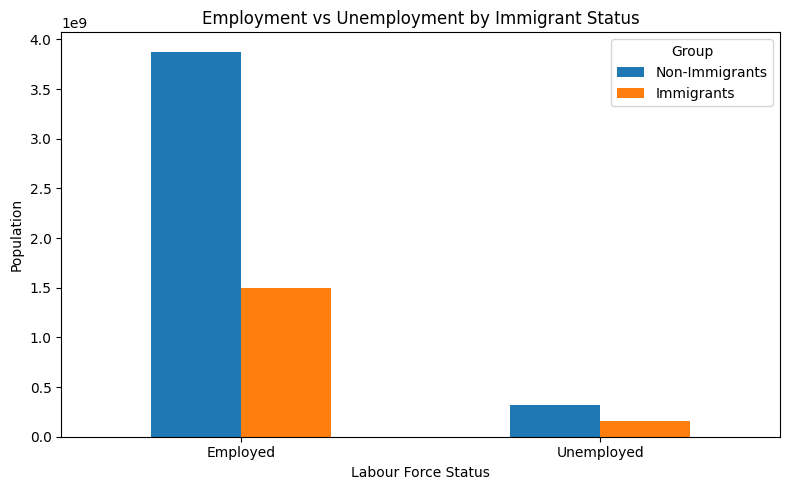

In [15]:
# 9. Visualization: Employment vs Unemployment by immigrant status
ax = summary.plot(kind="bar", figsize=(8, 5))
plt.title("Employment vs Unemployment by Immigrant Status")
plt.xlabel("Labour Force Status")
plt.ylabel("Population")
plt.xticks(rotation=0)
plt.legend(title="Group")
plt.tight_layout()
plt.show()

Model Development

In [16]:
# 10. Create binary target variable
# Employed = 1, Unemployed = 0
df_model["target"] = df_model["Labour force status (8)"].map({
    "Employed": 1,
    "Unemployed": 0
})


In [17]:

# 11. Select features for proof-of-concept model
features = [
    "Immigrant status and period of immigration (11):Non-immigrants[2]",
    "Immigrant status and period of immigration (11):Immigrants[3]",
]

X = df_model[features]
y = df_model["target"]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
display(y.value_counts())

Feature matrix shape: (5953500, 2)
Target distribution:


target
1    2976750
0    2976750
Name: count, dtype: int64

In [18]:
# 12. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# 13. Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Model Evaluation

In [20]:
# 14. Generate predictions
y_pred = model.predict(X_test)

In [21]:
# 15. Evaluate model performance
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.96      0.67    595350
           1       0.75      0.11      0.19    595350

    accuracy                           0.54   1190700
   macro avg       0.63      0.54      0.43   1190700
weighted avg       0.63      0.54      0.43   1190700

